In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
import torchvision.models as models


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(pretrained=True)
model.eval()
model = model.to(device)


d:\Satellite Imagery-Based Property Valuation(CDC)\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Satellite Imagery-Based Property Valuation(CDC)\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
target_layer = model.layer4


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
img_path = "../data/images/train/226039270.png"  # change ID as needed

raw_img = Image.open(img_path).convert("RGB")
input_tensor = transform(raw_img).unsqueeze(0).to(device)


In [6]:
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])


In [7]:
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


In [8]:
output = model(input_tensor)
class_idx = output.argmax(dim=1).item()

model.zero_grad()
output[0, class_idx].backward()


d:\Satellite Imagery-Based Property Valuation(CDC)\venv\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [9]:
grads = gradients[0]           # [1, C, H, W]
acts = activations[0]          # [1, C, H, W]

weights = grads.mean(dim=(2, 3), keepdim=True)
cam = (weights * acts).sum(dim=1).squeeze()

cam = F.relu(cam)
cam = cam.detach().cpu().numpy()
cam = cv2.resize(cam, (224, 224))
cam = cam / cam.max()


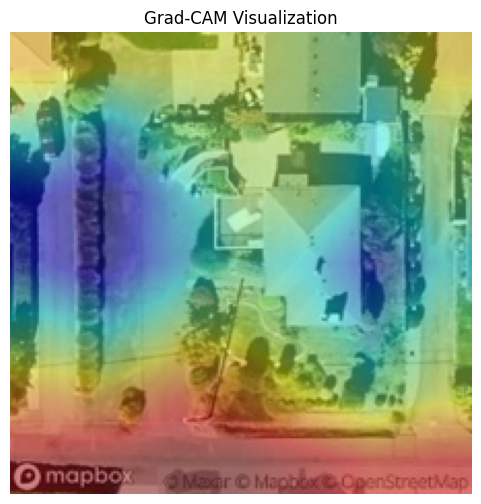

In [10]:
img_np = np.array(raw_img.resize((224, 224)))

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()
